# Feature Engineering & Categorical Encoding

This notebook implements essential feature engineering techniques used to prepare raw data for machine learning models. Feature engineering converts categorical variables, text, and temporal data into optimal numerical formats to maximize model predictive performance.

# Categorical Encoding Techniques
Label Encoding: Assigns a unique integer to each category (best for ordinal data with a clear ranking, like Low, Medium, High).
One-Hot Encoding: Creates binary columns for each unique category (ideal for nominal data without ranking, prevents the model from assuming false order).
Feature Hashing (The Hashing Trick): Converts categories into a fixed-size numerical vector using a hash function (great for high-cardinality features and memory efficiency).
Dataset Statistic Encoding: Replaces categories with structural dataset metrics, such as category frequency or percentage representation.
Cyclic + One-Hot Encoding: Transforms periodic variables (like hours, days, or months) using sine and cosine functions to preserve their circular nature, combined with binary flags.
Target Encoding: Replaces each category with the average expected value of the target variable for that category (powerful, but requires strict regularization to avoid leakage).
# Core Libraries & Packages Used
scikit-learn (sklearn): Provides industry-standard preprocessing tools (e.g., OneHotEncoder, LabelEncoder) and baseline machine learning algorithms.
pandas: Handles data manipulation, ingestion, and exploration. Used to convert CSV files into DataFrames, inspect structures via .info(), and view snapshots via .head().
numpy: Performs high-performance mathematical operations, vectorization, and statistical calculations (such as computing column modes, medians, and array transformations).
matplotlib: Generates data visualizations, data distribution plots, and correlation matrices to analyze features before and after encoding.
# 1. Library Imports
import pandas as pd: Loads the data manipulation library using the alias pd.
import numpy as np: Loads the mathematical calculation library using the alias np.
import matplotlib.pyplot as plt: Loads the data visualization library using the alias plt.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Data Ingestion
df_titanic = pd.read_csv('titanic.csv'): Converts the main Titanic CSV file into a DataFrame named df_titanic.
df_titanic_ages = pd.read_csv('titanic_missing_ages.csv'): Converts the missing ages CSV file into a separate DataFrame named df_titanic_ages.


In [5]:
df_titanic = pd.read_csv('titanic.csv')
df_titanic_ages = pd.read_csv('data.csv')

In [10]:
age_lookup = df_titanic_ages.set_index('Name')['Age']
df_titanic['Age'] = df_titanic['Age'].fillna(df_titanic['Name'].map(age_lookup))

In [11]:
mask = df_titanic['Name'].str.contains('Peduzzi, Mr. Joseph', na=False)
df_titanic.loc[mask, 'Age'] = 24
mask1 = df_titanic['Name'].str.contains('Icard, Miss. Amelie', na=False)
df_titanic.loc[mask1, 'Embarked'] = 'S'
mask2 = df_titanic['Name'].str.contains('Stone, Mrs. George Nelson (Martha Evelyn)', na=False, regex=False)
df_titanic.loc[mask2, 'Embarked'] = 'S'

In [12]:

df_titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
df_titanic_ages.head(5)

,Name,Age
0,"Moran, Mr. James",22
1,"Williams, Mr. Charles Eugene",23
2,"Masselmani, Mrs. Fatima",22
3,"Emir, Mr. Farred Chehab",29
4,"O'Dwyer, Miss. Ellen ""Nellie""",22


In [14]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1309 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1309 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


# Summary of the Dataset

It prints a condensed overview of the dataframe.

Key Insights Provided:

Total row count.

Complete column list.

Missing value counts.

Data type mapping.

Memory usage details

In [16]:

df_titanic_ages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    264 non-null    object
 1   Age     264 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.2+ KB



# Imputing Missing Titanic Passenger Ages via Dataframe Mapping

Fills missing values in df_titanic['Age'] by mapping passenger names to ages from a clean reference dataframe.

In [18]:
age_lookup=df_titanic_ages.set_index('Name')['Age']

# fill only the missing ages in df, matched by name
df_titanic['Age']= df_titanic['Age'].fillna(df_titanic['Name'].map(age_lookup))

In [19]:
df_titanic[df_titanic['Age'].isna()] 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [20]:

mask= df_titanic['Name'].str.contains('Peduzzi, Mr. Joseph', na=False)
df_titanic.loc[mask, 'Age'] =24

In [21]:
x=df_titanic.drop(['Cabin', 'Survived'], axis =1)

In [22]:
y= df_titanic['Survived']

In [23]:
x['Age']=x['Age'].fillna(x['Age'].median())

#Fill the missing single Fare with the median fare
x['Fare']=x['Fare'].fillna(x['Fare'].median())


#Fill the missing Embarked with the most coomon port(mode)
x['Embarked']=x['Embarked'].fillna(x['Embarked'].mode()[0]) 

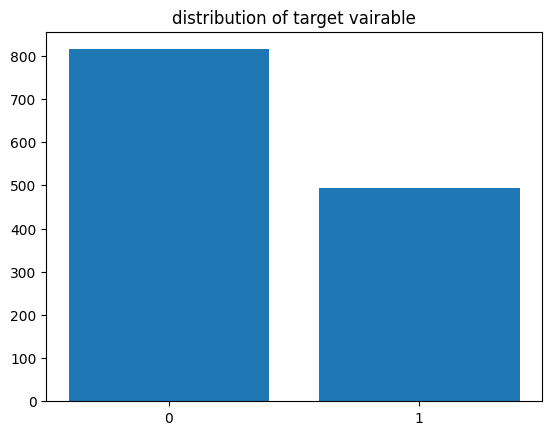

In [24]:
x_plot=y.value_counts()
plt.bar(x_plot.index, x_plot)
plt.gca().set_xticks([0,1])
plt.title('distribution of target vairable')
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

In [26]:
train=pd.DataFrame()
label=LabelEncoder()
for c in x.columns:
    if(x[c].dtype=='object'):
        train[c]=label.fit_transform(x[c])
    else:
        train[c]=x[c]

In [27]:

train.head(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,155,1,22.0,1,0,720,7.2500,2
1,2,1,286,0,38.0,1,0,816,71.2833,0
2,3,3,523,0,26.0,0,0,914,7.9250,2
3,4,1,422,0,35.0,1,0,65,53.1000,2
4,5,3,22,1,35.0,0,0,649,8.0500,2


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

In [29]:

def logistic(x,y):
    x_train, x_test, y_train, y_test=train_test_split(x, y, random_state=42, test_size=0.2)
    lr=LogisticRegression(max_iter=1000)
    lr.fit(x_train, y_train)
    y_pre=lr.predict(x_test)
    print('Accuracy:', accuracy_score(y_test, y_pre))

In [30]:
logistic (train,y)

Accuracy: 0.8435114503816794


In [31]:

df_titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [32]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
train_2 = pd.get_dummies(x,columns=['Sex', 'Embarked'],dtype=np.int8)

In [34]:

train_2.head(5)

,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,1,0,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,0,1,0,0
2,3,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,0,0,0,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,0,0,0,1
4,5,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,1,0,0,1


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

In [36]:
def logistic(x, y):
    x_train2, x_test2, y_train2, y_test2 = train_test_split(
        x, y, random_state=42, test_size=0.2)

    lr = LogisticRegression(max_iter=1000)
    lr.fit(x_train2, y_train2)
    y_pre2 = lr.predict(x_test2)
    print('Accuracy:', accuracy_score(y_test2, y_pre2))

In [ ]:
logistic (train_2,y)

ValueError: could not convert string to float: 'Mack, Mrs. (Mary)'